## 6. Design and implement a Convolutional Neural Network (CNN) for image classification 

#### import libraries

In [2]:
import os
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

#### Define our dataset paths

In [ ]:
DATASET_DIR = "/mnt/d/Third Year/DL/Assignments/Exp_6/dataset/Forest Fire/Forest Fire_Dataset                               "

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)
print("Test path:", TEST_DIR)

Train path: /mnt/d/Third Year/DL/Assignments/Exp_6/dataset/Forest Fire/Forest Fire_Dataset/train
Validation path: /mnt/d/Third Year/DL/Assignments/Exp_6/dataset/Forest Fire/Forest Fire_Dataset/val
Test path: /mnt/d/Third Year/DL/Assignments/Exp_6/dataset/Forest Fire/Forest Fire_Dataset/test


#### Image preprocessing and augmentation

In [4]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#### Load the datasets

In [5]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Classes: ['fire', 'nofire', 'smoke', 'smokefire']
Class mapping: {'fire': 0, 'nofire': 1, 'smoke': 2, 'smokefire': 3}
Training images: 3200
Validation images: 800
Test images: 800


#### Create DataLoaders


In [6]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 100
Validation batches: 25
Test batches: 25


#### Visualize sample images

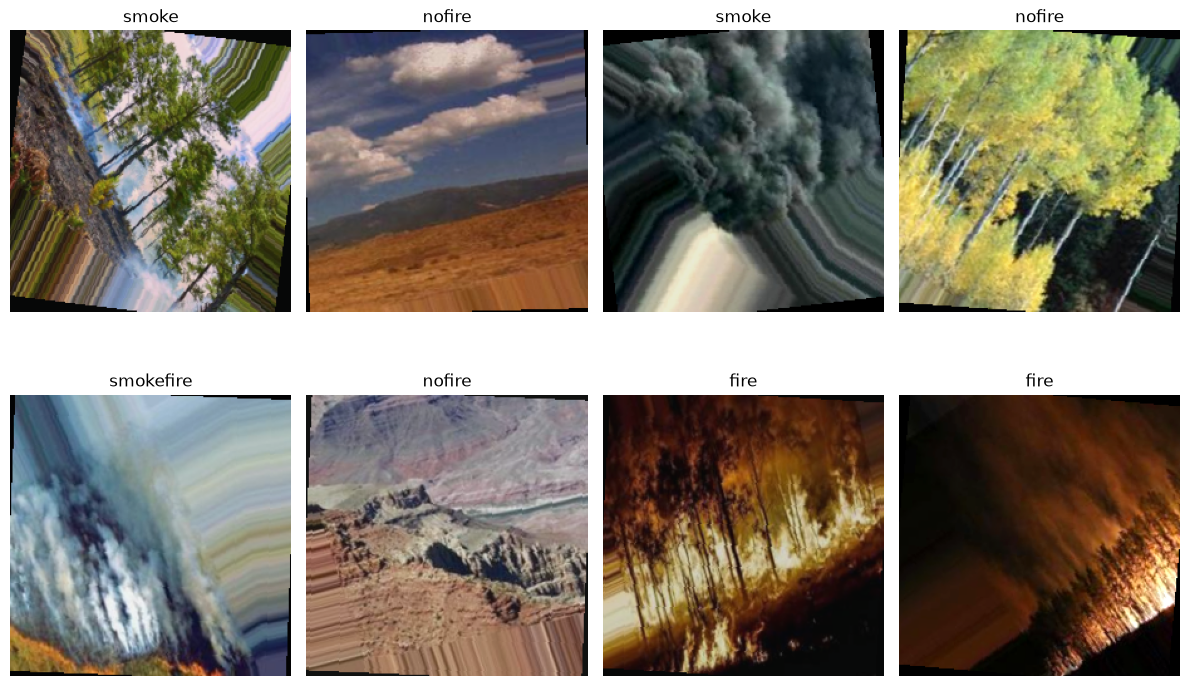

In [7]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):
    image = images[i].permute(1, 2, 0).numpy()

    # Undo normalization for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Define our CNN

In [8]:
import torch.nn as nn
import torch.nn.functional as F


class FireSmokeCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(FireSmokeCNN, self).__init__()

        # Convolutional Block 1
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Block 2
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Block 3
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1
        )
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolutional Block 4
        self.conv4 = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            padding=1
        )
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected layer
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))

        x = self.pool2(F.relu(self.bn2(self.conv2(x))))

        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = self.pool4(F.relu(self.bn4(self.conv4(x))))

        x = self.global_pool(x)

        x = torch.flatten(x, 1)

        x = self.dropout(x)

        x = self.fc(x)

        return x

#### Create the model

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FireSmokeCNN(num_classes=len(train_dataset.classes))
model = model.to(device)

print(model)

FireSmokeCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool4): MaxPo

#### Count model parameters

In [10]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 390,404
Trainable parameters: 390,404


#### Define Loss Function and Optimizer

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


#### Create the training function

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

#### Create validation function

In [13]:
def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

#### Train the CNN

In [14]:
NUM_EPOCHS = 20

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # Save the best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "../model/best_fire_smoke_cnn.pth")
        print("  ✓ Best model saved")

Epoch [1/20] Train Loss: 0.7205 Train Acc: 0.7178 Val Loss: 0.5060 Val Acc: 0.7812
  ✓ Best model saved
Epoch [2/20] Train Loss: 0.6457 Train Acc: 0.7503 Val Loss: 0.6532 Val Acc: 0.6975
Epoch [3/20] Train Loss: 0.5700 Train Acc: 0.7847 Val Loss: 0.5131 Val Acc: 0.8013
  ✓ Best model saved
Epoch [4/20] Train Loss: 0.5633 Train Acc: 0.7869 Val Loss: 0.4500 Val Acc: 0.8100
  ✓ Best model saved
Epoch [5/20] Train Loss: 0.5469 Train Acc: 0.8022 Val Loss: 0.5287 Val Acc: 0.8087
Epoch [6/20] Train Loss: 0.5399 Train Acc: 0.8013 Val Loss: 0.4211 Val Acc: 0.8425
  ✓ Best model saved
Epoch [7/20] Train Loss: 0.5112 Train Acc: 0.8075 Val Loss: 0.4389 Val Acc: 0.8275
Epoch [8/20] Train Loss: 0.4956 Train Acc: 0.8109 Val Loss: 0.3671 Val Acc: 0.8538
  ✓ Best model saved
Epoch [9/20] Train Loss: 0.4689 Train Acc: 0.8228 Val Loss: 0.3463 Val Acc: 0.8650
  ✓ Best model saved
Epoch [10/20] Train Loss: 0.4707 Train Acc: 0.8272 Val Loss: 0.3989 Val Acc: 0.8562
Epoch [11/20] Train Loss: 0.4600 Train Acc:

#### Load the best model

In [15]:
best_model_path = "../model/best_fire_smoke_cnn.pth"

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


#### Evaluate on the test dataset

In [16]:
test_loss, test_accuracy = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.8212
Test Accuracy: 0.7338
Test Accuracy: 73.38%


#### Generate predictions for all test images

In [17]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

print("Total predictions:", len(all_predictions))
print("Total actual labels:", len(all_labels))

Total predictions: 800
Total actual labels: 800


#### Classification Report

In [18]:
class_names = test_dataset.classes

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

        fire     0.9470    0.6250    0.7530       200
      nofire     0.9635    0.9250    0.9439       200
       smoke     0.6061    1.0000    0.7547       200
   smokefire     0.5274    0.3850    0.4451       200

    accuracy                         0.7338       800
   macro avg     0.7610    0.7337    0.7242       800
weighted avg     0.7610    0.7338    0.7242       800



#### Confusion Matrix

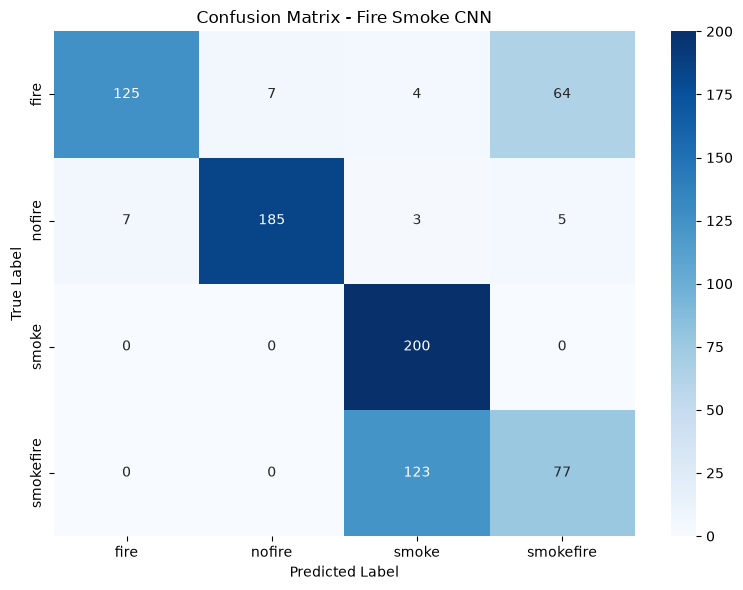

In [19]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fire Smoke CNN")
plt.tight_layout()
plt.show()

#### Plot Training and Validation Accuracy

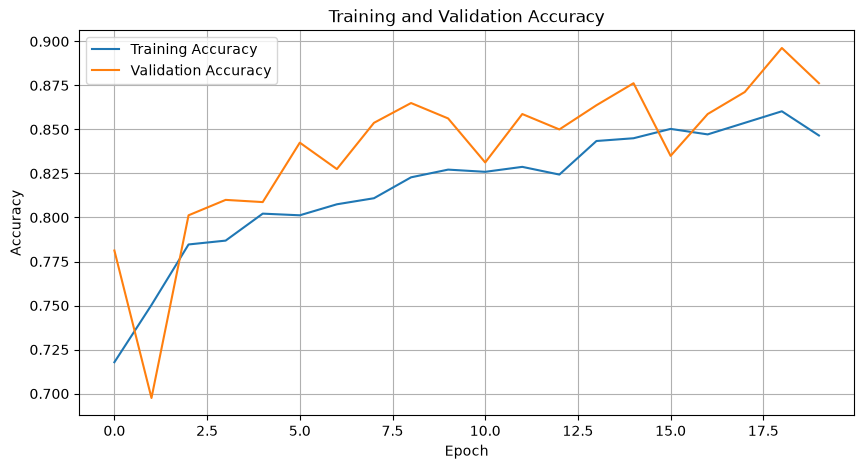

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(history["train_accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

#### Plot Training and Validation Loss

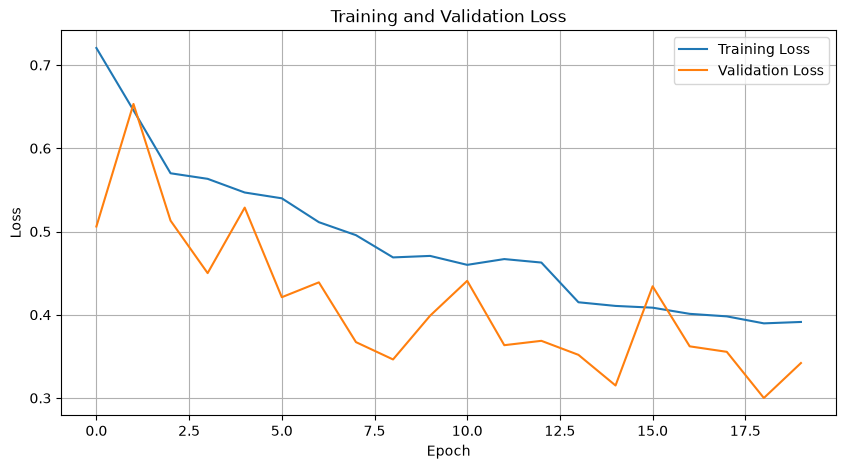

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

#### Use the 23 unseen tester images

In [22]:
from PIL import Image

TESTER_DIR = "../dataset/Forest Fire/Forest_Fire_Tester"

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")

    image_tensor = val_test_transform(image)
    image_tensor = image_tensor.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()

    return (
        class_names[predicted_class],
        probabilities[0].cpu().numpy()
    )

####  getting the Forest Fire_Tester

In [ ]:
import os

# Main project folder
PROJECT_DIR = "/mnt/d/Third Year/DL/Assignments/Exp_6"

print("Searching for Forest Fire_Tester...")
print("Project folder exists:", os.path.exists(PROJECT_DIR))

# Search all folders inside the project
found_folders = []

for root, dirs, files in os.walk(PROJECT_DIR):
    for directory in dirs:
        if directory.lower() == "forest fire_tester":
            found_folders.append(os.path.join(root, directory))

# Display results
print("\nFolders found:")

if found_folders:
    for folder in found_folders:
        print(folder)

    # Use the first matching folder
    TESTER_DIR = found_folders[0]

    print("\nUsing tester folder:")
    print(TESTER_DIR)

    # Find images
    tester_images = [
        f for f in os.listdir(TESTER_DIR)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print("\nNumber of tester images:", len(tester_images))
    print("First few images:", tester_images[:5])

else:
    print("Forest_Fire_Tester folder was NOT found.")

    print("\nLet's check the dataset folders that actually exist:")

    for root, dirs, files in os.walk(PROJECT_DIR):
        if "dataset" in root.lower():
            print(root)

Searching for Forest Fire_Tester...
Project folder exists: True

Folders found:
/mnt/d/Third Year/DL/Assignments/Exp_6/dataset/Forest Fire/Forest Fire_Tester

Using tester folder:
/mnt/d/Third Year/DL/Assignments/Exp_6/dataset/Forest Fire/Forest Fire_Tester

Number of tester images: 23
First few images: ['1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg']


#### Predict all unseen tester images

In [ ]:

import pandas as pd
import os

results = []

# Put model in evaluation mode
model.eval()

# Sort filenames normally instead of converting names to integers
for image_name in sorted(tester_images):

    image_path = os.path.join(TESTER_DIR, image_name)

    # Predict image
    predicted_class, probabilities = predict_image(image_path)

    # Get confidence of predicted class
    predicted_index = probabilities.argmax()
    confidence = probabilities[predicted_index] * 100

    # Store result
    results.append({
        "Image": image_name,
        "Predicted Class": predicted_class,
        "Confidence (%)": round(confidence, 2)
    })


# Convert results to a DataFrame
results_df = pd.DataFrame(results)

print("=" * 60)
print("PREDICTIONS FOR UNSEEN TESTER IMAGES")
print("=" * 60)

display(results_df)

PREDICTIONS FOR UNSEEN TESTER IMAGES


,Image,Predicted Class,Confidence (%)
0,1.jpg,smokefire,65.050003
1,10.jpg,smoke,88.300003
2,11.jpg,nofire,71.160004
3,12.jpg,nofire,94.940002
4,13.jpg,nofire,88.290001
5,14.jpg,nofire,67.180000
6,15.jpg,smokefire,95.110001
7,16.jpg,smokefire,57.430000
8,17.jpg,smoke,97.430000
9,18.jpg,smoke,96.709999


#### Final test set evaluation

In [ ]:


# Load the best model saved during training
best_model_path = "../model/best_fire_smoke_cnn.pth"

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device,
        weights_only=True
    )
)

model = model.to(device)
model.eval()

# Evaluate on the test dataset
test_loss, test_accuracy = validate(
    model,
    test_loader,
    criterion,
    device
)

print("=" * 50)
print("FINAL TEST SET RESULTS")
print("=" * 50)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

FINAL TEST SET RESULTS
Test Loss     : 0.8212
Test Accuracy : 0.7338
Test Accuracy : 73.38%


#### Classification report and confusion matrix

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        fire     0.9470    0.6250    0.7530       200
      nofire     0.9635    0.9250    0.9439       200
       smoke     0.6061    1.0000    0.7547       200
   smokefire     0.5274    0.3850    0.4451       200

    accuracy                         0.7338       800
   macro avg     0.7610    0.7337    0.7242       800
weighted avg     0.7610    0.7338    0.7242       800


Confusion Matrix:
[[125   7   4  64]
 [  7 185   3   5]
 [  0   0 200   0]
 [  0   0 123  77]]


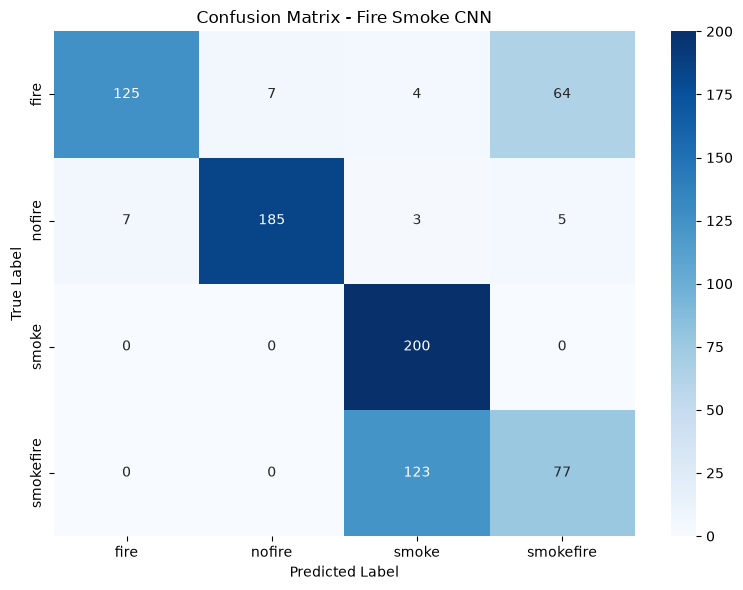

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Store predictions and actual labels
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        # Move images to GPU/CPU
        images = images.to(device)

        # Get model predictions
        outputs = model(images)

        # Select class with highest probability
        predictions = torch.argmax(outputs, dim=1)

        # Move results back to CPU
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())


# Classification Report

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)


# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

print("\nConfusion Matrix:")
print(cm)


# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Fire Smoke CNN")
plt.tight_layout()
plt.show()

#### Training and Validation accuracy

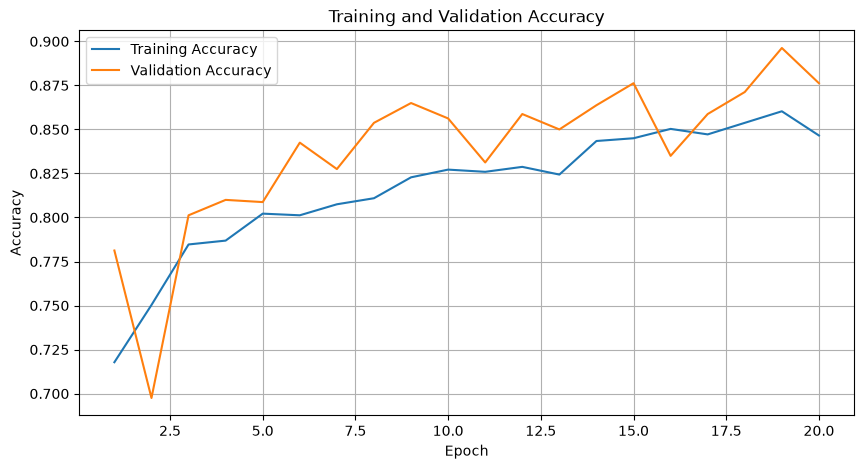

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(history["train_accuracy"]) + 1),
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    range(1, len(history["val_accuracy"]) + 1),
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

#### Training and validation loss

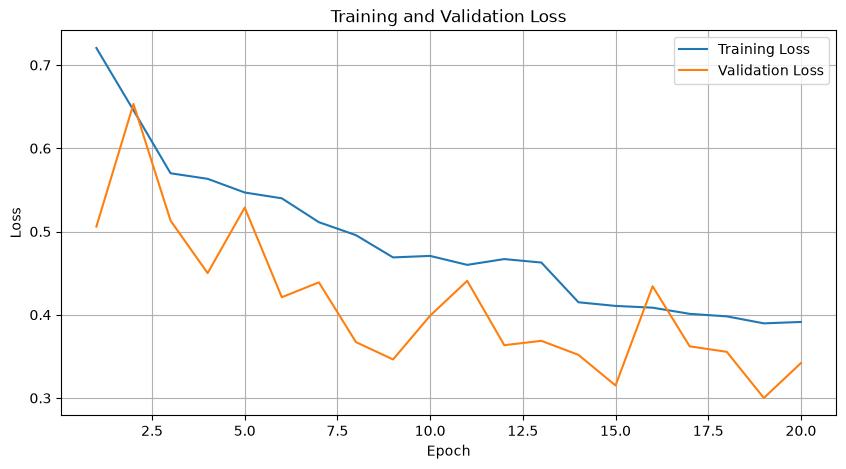

In [ ]:


plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(history["train_loss"]) + 1),
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    range(1, len(history["val_loss"]) + 1),
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()